# 06_evapotranspiration

This notebook combines the products of the previous notebooks to estimate instantaneous evapotranspiration (ET) with a one-source energy balance (OSEB) model. It loads the surface property stack from notebook 05 and the flight window weather data, computes each term of the surface energy balance (net radiation, ground heat flux, sensible heat flux, and latent heat as the residual), and runs the model twice: once with the calibrated LST and once with the uncalibrated brightness temperature. A Bowen-ratio energy balance (BREB) from the weather station serves as an independent reference.

In [1]:
import matplotlib.pyplot as plt
import os
import modules.air, modules.surface, modules.fluxes
import rasterio as rio

from modules.utils import *
from modules.ws import *

In [2]:
DATE = '20250807'
METEO_DIR = "data/ancillary/weather"
#DATES = ['20250622', '20250807', '20250813', '20250814']
weather_station_x, weather_Station_y = 549987.076, 5620528.830

### Weather data

Let's load the flight window and the on-site weather station data for this flight, as well as the 10-minute data from the nearby Luční bouda station (used later for the incoming shortwave radiation).

In [3]:
flight_start, flight_end = load_flight_window(DATE)
weather_df = load_meteo_data(DATE, METEO_DIR)
weather_df = weather_df[weather_df.datetime.between(flight_start, flight_end)]

In [4]:
lucni_b_df = download_chmu_10min(DATE[:6]).reset_index()
lucni_b_df = lucni_b_df[lucni_b_df.DT.between(flight_start-timedelta(minutes=30), flight_end+timedelta(minutes=30))]

https://opendata.chmi.cz/meteorology/climate/historical/data/10min/2025/10m-0-203-0-11633-202508.json


Take the median of each weather variable over the flight window.

In [5]:
cols = ['hukseflux_heat_flux', 'nr_lite2_net_radiation',
        'rvt81_temp_2m', 'rvt81_rh_2m', 'ws200_wind_speed', 'air_pressure']
median_weather = weather_df[cols].median()
air_temperature = median_weather['rvt81_temp_2m']
relative_humidity = median_weather['rvt81_rh_2m']
heat_flux = median_weather['hukseflux_heat_flux']
net_radiation = median_weather['nr_lite2_net_radiation']
air_pressure = median_weather['air_pressure']
wind_speed = median_weather['ws200_wind_speed']

Now let's assemble the air properties: the air properties (density, heat capacity, vapour pressure, psychrometric constant) are first derived from the station temperature, humidity and pressure; `ra` is the neutral aerodynamic resistance from `build_surface`.

In [6]:
air_properties = modules.air.get_air_properties(air_temperature, relative_humidity, air_pressure)
air_properties

{'es': np.float64(1.6142324679094995),
 'ea': np.float64(1.0088952924434371),
 'vpd': np.float64(0.6053371754660624),
 'delta': np.float64(0.10462919263531238),
 'lam': np.float64(2467591.8499999996),
 'gamma': np.float64(0.05690213557023517),
 'rho': np.float64(1.0407929477832358),
 'rho_cp': np.float64(1054.3232561044179),
 'Ta_K': np.float64(287.29999999999995)}

### Build the surface

Assemble every temperature-independent surface field the flux model needs: albedo, emissivity, roughness lengths and the (neutral) aerodynamic resistance; from the stack and the station wind speed.

In [7]:
data, prof = modules.surface.load_stack(f'results/05_correct_emissivity/stacks/{DATE}_stack.tif', downsample=1)
surf = modules.surface.build_surface(data, u=wind_speed)

print('grid:', data['lst_cal'].shape)
print('valid:', int(surf['valid'].sum()), '/', surf['valid'].size)
for k in ('albedo', 'emis', 'z0m', 'ra'):
    v = surf[k][np.isfinite(surf[k])]
    print('{} median {}; min {}; max {}'.format(k, np.median(v), v.min(), v.max()))
print('ra land', np.nanmedian(surf['ra'][surf['land']]))
print('dH/dTs', air_properties['rho_cp'] / np.nanmedian(surf['ra'][surf['land']]), 'W/m2/degC')

c:\Users\dance\OneDrive\Počítač\škola\diplomka\masters-thesis\modules\surface.py:68: RuntimeWarning: divide by zero encountered in divide
  num = np.log(zm / z0m) * np.log(zt / z0h)
c:\Users\dance\OneDrive\Počítač\škola\diplomka\masters-thesis\modules\surface.py:68: RuntimeWarning: invalid value encountered in log
  num = np.log(zm / z0m) * np.log(zt / z0h)


grid: (2235, 3262)
valid: 4469159 / 7290570
albedo median 0.10999999940395355; min 0.05999999865889549; max 0.15000000596046448
emis median 0.9800000190734863; min 0.9599999785423279; max 0.9900000095367432
z0m median 0.04247766360640526; min -4.702467519315779e-16; max 0.10000000149011612
ra median 59.378941505373895; min 42.18792987884049; max 500.0
ra land 59.32511785690086
dH/dTs 17.771953839983414 W/m2/degC


## Estimate the energy balance components

### Net radiation

Net radiation balances absorbed shortwave and longwave against emitted longwave (Eq. 18). Incoming longwave is estimated from air temperature and humidity via the Brutsaert (1975) clear-sky emissivity (Eq. 19); incoming shortwave is the median global radiation from Luční bouda.

In [8]:
Rl = modules.fluxes.incoming_longwave(air_temperature+273.15, modules.air.actual_vapour_pressure(air_temperature, relative_humidity))
print('Rl_down {:.0f} W/m2'.format(Rl))     

Rl_down 297 W/m2


In [9]:
Rs = np.median(lucni_b_df['RGLB10'])
print('Rs_down {:.0f} W/m2'.format(Rs))     

Rs_down 661 W/m2


In [10]:
Rn = modules.fluxes.net_radiation(data['lst_cal'], surf['albedo'], surf['emis'], incoming_shortwave=Rs, incoming_longwave=Rl)
print('Rn land median {:.0f} W/m2'.format(np.nanmedian(Rn[surf['land']])))

Rn land median 436 W/m2


### Ground heat flux

The ground heat flux is taken as a fixed fraction of net radiation, `G = c·Rn` (Eq. 20). First the fraction `c` is anchored to the weather station, where both the soil heat flux and net radiation are measured (`c = G_station / Rn_station`).

In [11]:
c_land = modules.fluxes.calc_c_land(heat_flux, net_radiation) #anchor to weather station
print('c_land anchored = {:.3f}'.format(c_land))

c_land anchored = 0.229


Apply the anchored fraction to the net radiation field to obtain `G` across the scene; open water is handled separately.

In [12]:
G = modules.fluxes.ground_heat(Rn, surf['water'], c_land)
print('G land median {:.0f} W/m2'.format(np.nanmedian(G[surf['land']])))

G land median 100 W/m2


### Sensible heat flux

The sensible heat flux is `H = ρc_p (Ts − Ta) / ra` (Eq. 21), evaluated at the 2 m reference height. 

In [13]:
H = modules.fluxes.sensible_heat(data['lst_cal'], air_temperature, surf['ra'], air_properties['rho_cp']) ### No MO
print('H land median {:.0f} W/m2'.format(np.nanmedian(H[surf['land']])))

H land median 156 W/m2


### Latent heat flux

The latent heat flux is then obtained as the residual of the energy balance, `LE = Rn − G − H` (Eq. 23).

In [14]:
L = Rn - G - H
print('L land median {:.0f} W/m2'.format(np.nanmedian(L[surf['land']])))

L land median 182 W/m2


Now let's compare the modelled partitioning against an independent Bowen-ratio reference from the weather station.

### Bowen ratio energy balance

The BREB is computed from the station's two-height temperature and humidity gradients (Eq. 24), giving the sensible and latent heat fluxes, the Bowen ratio β and the evaporative fraction EF used as the reference.

In [15]:
brb = modules.air.bowen_from_meteo(weather_df)
brb['datetime'] = weather_df.datetime.values
brb['EF'] = 1/(1+brb['beta'])
brb

,beta,dT,de,H_breb,LE_breb,energy,gamma,datetime,EF
403,0.899948,-1.9,-0.120103,180.027715,200.042285,380.070,0.056888,2025-08-07 13:44:00,0.526330
404,1.057694,-1.7,-0.091442,197.137600,186.384400,383.522,0.056893,2025-08-07 13:45:00,0.485981
405,0.961630,-1.7,-0.100596,189.955280,197.534720,387.490,0.056904,2025-08-07 13:46:00,0.509780
406,0.839783,-1.7,-0.115214,172.490320,205.398680,377.889,0.056915,2025-08-07 13:47:00,0.543542
407,0.815095,-1.7,-0.118727,169.682275,208.174725,377.857,0.056926,2025-08-07 13:48:00,0.550935
408,0.993715,-1.8,-0.103094,181.902294,183.052706,364.955,0.056915,2025-08-07 13:49:00,0.501576
409,0.918739,-1.7,-0.105301,174.059399,189.454601,363.514,0.056908,2025-08-07 13:50:00,0.521176
410,1.419064,-1.7,-0.068174,210.942763,148.649237,359.592,0.056908,2025-08-07 13:51:00,0.413383
411,0.725157,-1.7,-0.133434,153.471303,211.638697,365.110,0.056918,2025-08-07 13:52:00,0.579657
412,0.970577,-2.1,-0.123083,179.013648,184.440352,363.454,0.056886,2025-08-07 13:53:00,0.507465


In [16]:
ref = brb[['beta', 'EF', 'H_breb', 'LE_breb', 'energy']].median()
print(ref.round(2).to_string())

beta         0.98
EF           0.50
H_breb     179.52
LE_breb    187.95
energy     370.57


### Aerodynamic resistance under non-neutral stability (exploratory)

The sensible heat flux depends on the aerodynamic resistance `ra`, which itself depends on atmospheric stability. `build_surface` computes `ra` under a neutral assumption (turbulence only from the wind). That is questionable here: the flights are around solar noon, when the sunlit peat surface is much warmer than the overlying air, so the surface layer is likely convectively unstable and buoyancy enhances mixing. Neutral `ra` is then too high, which would underestimate `H` and overestimate ET.

The resistance is therefore recomputed with the Monin–Obukhov stability corrections (`psi_m`, `psi_h`; Paulson, 1970). Stability is set by the Obukhov length `L`, derived from the weather station's measured sensible heat (`obukhov_from_station`), which comes from the Bowen ratio balance of the 0.2 m and 2 m temperature and humidity gradients. Thus, the atmospheric state is fixed by observation and is identical for the calibrated and uncalibrated runs.

In [17]:
H_ref = ref['H_breb']
L_weather_station, ustar = modules.air.obukhov_from_station(H_ref, wind_speed, air_properties['Ta_K'], air_properties['rho_cp'])

In [18]:
surf_mo = modules.surface.build_surface(data, u=wind_speed, L=L_weather_station)
ra_neutral, ra_mo = surf['ra'], surf_mo['ra']

H_mo = modules.fluxes.sensible_heat(data['lst_cal'], air_temperature, ra_mo, air_properties['rho_cp'])
LE_neutral = Rn - G - H
LE_MO = Rn - G - H_mo

c:\Users\dance\OneDrive\Počítač\škola\diplomka\masters-thesis\modules\surface.py:70: RuntimeWarning: divide by zero encountered in divide
  num = ((np.log(zm / z0m) - psi_m(zm / L) + psi_m(z0m / L)) * (np.log(zt / z0h) - psi_h(zt / L) + psi_h(z0h / L)))
c:\Users\dance\OneDrive\Počítač\škola\diplomka\masters-thesis\modules\surface.py:70: RuntimeWarning: invalid value encountered in log
  num = ((np.log(zm / z0m) - psi_m(zm / L) + psi_m(z0m / L)) * (np.log(zt / z0h) - psi_h(zt / L) + psi_h(z0h / L)))


This comparison is exploratory and was left out of the thesis (would delve too much into ET), but it is own implementation to see why the stability correction is done rather than a neutral assumption. Below, the neutral and MO-corrected resistances are compared against the `H` estimated by the station. As expected, the neutral run inflates `ra` and depresses `H`; the corrected `H` sits closer to the station reference.

In [ ]:
land = surf['land']
m = lambda a: float(np.nanmedian(a[land]))
b = lambda Hx: np.nanmedian((Hx / np.clip(Rn - G - Hx, 1, None))[land])
print(f"land medians\tneutral\tMO")
print(f"ra [s/m]\t{m(ra_neutral):7.0f}\t{m(ra_mo):7.0f}")
print(f"H [W/m2]\t{m(H):7.0f}\t{m(H_mo):7.0f}")
print(f"LE [W/m2]\t{m(LE_neutral):7.0f}  {m(LE_MO):7.0f}")
print(f"model beta\t{b(H):7.2f}  {b(H_mo):7.2f}")

land medians          neutral    MO
  ra   [s/m]               59       50
  H    [W/m2]             156      184
  LE   [W/m2]             182      153
  model beta             0.85     1.20


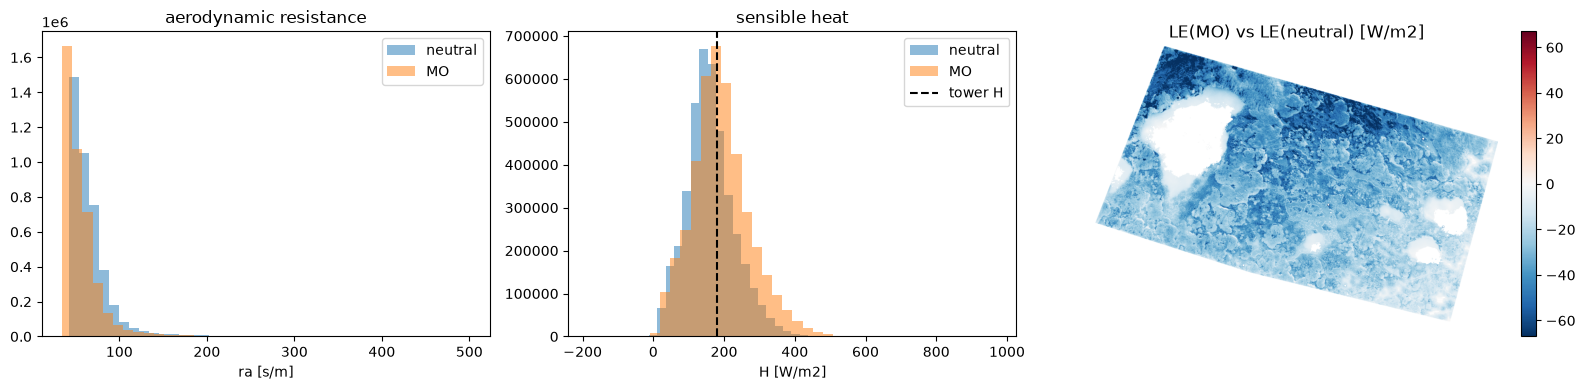

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].hist(ra_neutral[land], 40, alpha=.5, label='neutral')
ax[0].hist(ra_mo[land], 40, alpha=.5, label='MO')
ax[0].set(xlabel='ra [s/m]', title='aerodynamic resistance')
ax[0].legend()

ax[1].hist(H[land], 40, alpha=.5, label='neutral')
ax[1].hist(H_mo[land], 40, alpha=.5, label='MO')
ax[1].axvline(ref['H_breb'], color='k', ls='--', lw=1.5, label='tower H')
ax[1].set(xlabel='H [W/m2]', title='sensible heat')
ax[1].legend()

d = np.where(land, LE_MO - LE_neutral, np.nan)
lim = np.nanpercentile(np.abs(d), 98)
im = ax[2].imshow(d, cmap='RdBu_r', vmin=-lim, vmax=lim)
plt.colorbar(im, ax=ax[2], fraction=.05)
ax[2].set(title='LE(MO) vs LE(neutral) [W/m2]')
ax[2].axis('off')
plt.tight_layout()

### ET

Let's compose everything now.

In [24]:
energy_fluxes = {"Rl": 
Rl, "Rs": Rs, 'Rn_station': net_radiation, 'G_station': heat_flux}

Now we are ready to run OSEB twice with everything fixed except the thermal input: once with the calibrated LST (`lst_cal`) and once with the uncalibrated brightness temperature (`tb_uncal`). The difference in ET between the two runs isolates the effect of the thermal calibration.

In [25]:
cal = modules.fluxes.run_oseb(data['lst_cal'], surf_mo, air_properties, air_temperature, energy_fluxes)
uncal = modules.fluxes.run_oseb(data['tb_uncal'], surf_mo,air_properties, air_temperature ,energy_fluxes)

dET = cal['ET'] - uncal['ET']
dLST = data['lst_cal'] - data['tb_uncal']

In [26]:
land, water, valid = surf_mo['land'], surf_mo['water'], surf_mo['valid']

med = lambda a, m: float(np.nanmedian(a[m]))
print('\tcal\tuncal\tΔ(cal−uncal)')
for k in ['Rn','G','H','LE']:
    print('{}\tland\t{:.0f}\t{:.0f}\t{:+.1f} W/m2'.format(k, med(cal[k],land), med(uncal[k],land), med(cal[k]-uncal[k],land)))
print('ET\tland\t{:.3f}\t{:.3f}\t{:+.3f} mm/h'.format(med(cal['ET'],land), med(uncal['ET'],land), med(dET,land)))
print('ET\twater\t{:.3f}\t{:.3f}\t{:+.3f} mm/h'.format(med(cal['ET'],water), med(uncal['ET'],water), med(dET,water)))
print('\nΔLST land median {:+.3f} °C\t|ΔET| land median {:.3f} mm/h'.format(med(dLST,land), med(np.abs(dET),land)))
print('dLE/dTs (land) = {:.1f} W/m2/°C'.format(np.nanmedian(((cal['LE']-uncal['LE'])[land])/np.where(np.abs(dLST[land])>0.05, dLST[land], np.nan))))

	cal	uncal	Δ(cal−uncal)
Rn	land	436	467	-31.7 W/m2
G	land	100	107	-7.3 W/m2
H	land	184	65	+114.6 W/m2
LE	land	153	295	-138.9 W/m2
ET	land	0.224	0.430	-0.203 mm/h
ET	water	nan	nan	+nan mm/h

ΔLST land median +5.667 °C	|ΔET| land median 0.203 mm/h


C:\Users\dance\AppData\Local\Temp\ipykernel_161716\3612309315.py:3: RuntimeWarning: All-NaN slice encountered
  med = lambda a, m: float(np.nanmedian(a[m]))


dLE/dTs (land) = -25.4 W/m2/°C


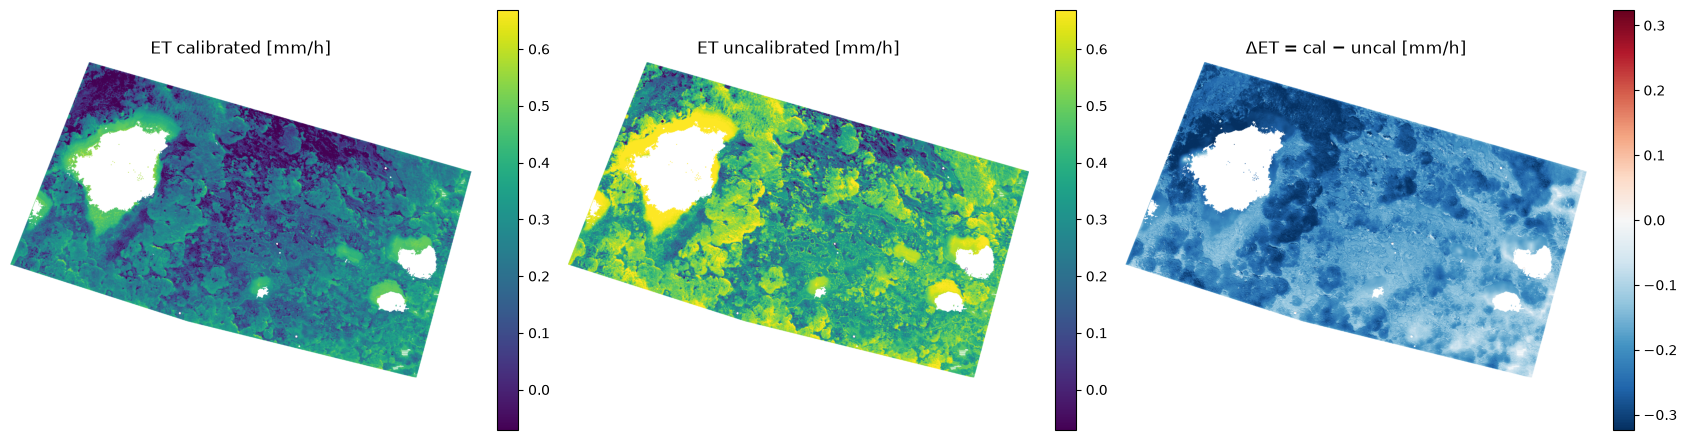

In [27]:
et_both = np.concatenate([cal['ET'][valid], uncal['ET'][valid]]) 
lo, hi = np.nanpercentile(et_both, [2, 98]) 
lim = np.nanpercentile(np.abs(dET[valid]), 98) 
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5)) 
panels = [(cal['ET'], 'ET calibrated [mm/h]', 'viridis', {'vmin': lo, 'vmax': hi}),
           (uncal['ET'],'ET uncalibrated [mm/h]', 'viridis', {'vmin': lo, 'vmax': hi}), 
           (dET, 'ΔET = cal − uncal [mm/h]','RdBu_r', {'vmin': -lim, 'vmax': lim})] 
for a, (arr, ttl, cm, kw) in zip(ax, panels): 
    im = a.imshow(np.where(valid, arr, np.nan), cmap=cm, **kw) 
    plt.colorbar(im, ax=a, fraction=.05)
    a.set_title(ttl)
    a.axis('off')
plt.tight_layout()

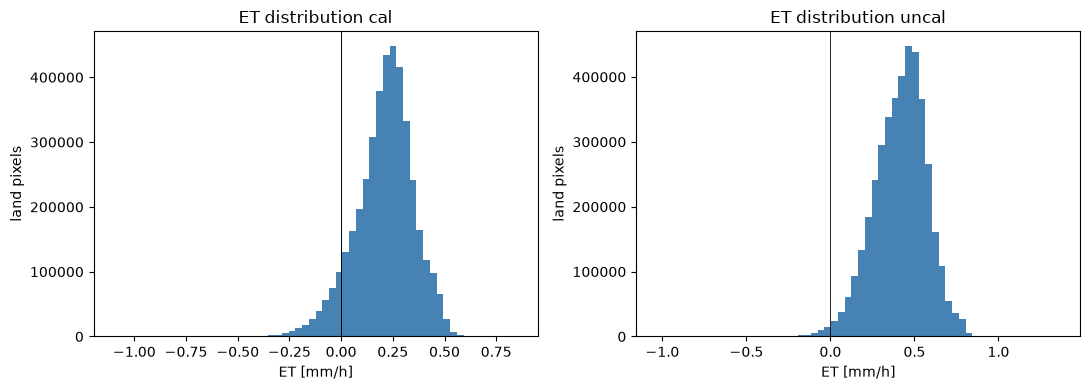

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(cal['ET'].flatten(), 60, color='steelblue')
ax[0].axvline(0, color='k', lw=.6)
ax[0].set(xlabel='ET [mm/h]', ylabel='land pixels', title='ET distribution cal')
ax[1].hist(uncal['ET'].flatten(), 60, color='steelblue')
ax[0].axvline(0, color='k', lw=.6)
ax[1].axvline(0, color='k', lw=.6)
ax[1].set(xlabel='ET [mm/h]', ylabel='land pixels', title='ET distribution uncal')
plt.tight_layout()

### Save the ET stack

Collect all model outputs: the two thermal inputs, the four energy balance components and ET for both runs, plus context metadata; into a single multi-band GeoTIFF for further analysis and figures in a separate notebook. TODO: add it from uni pc

In [29]:
layers = {'lst_cal': data['lst_cal'], 'tb_uncal':data['tb_uncal'], 'Rn_cal':cal['Rn'], 'Rn_uncal':uncal['Rn'],
          'G_cal': cal['G'], 'G_uncal':uncal['G'], 'H_cal': cal['H'], 'H_uncal':uncal['H'], 'LE_cal':cal['LE'], 'LE_uncal':uncal['LE'],
          'ET_cal': cal['ET'], 'ET_uncal': uncal['ET'], 'dET': dET, 'ra': surf['ra'], 'canopy_height': surf['h_c'], 'valid':valid}

context = {
    'date': DATE,
    'flight_window': [str(flight_start), str(flight_end)],
    'weather': weather_df.to_json(),
    'radiation': {'Rs_down': Rs, 'Rl_down': Rl},
    'bowen_ws': ref.to_json(),
    'air_properties': air_properties,
    'constants': {'c_land': c_land,}
}

C:\Users\dance\AppData\Local\Temp\ipykernel_161716\176249918.py:8: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  'weather': weather_df.to_json(),


In [30]:
out_path = 'results/06_evapotranspiration'
os.makedirs(out_path, exist_ok=True)
out = modules.fluxes.save_et_stack(f'{out_path}/{DATE}_et_stack.tif', layers, prof, context)
brb.to_parquet(f'{out_path}/{DATE}_breb.parquet')

In [31]:
prof

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 3262, 'height': 2235, 'count': 7, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 33N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(0.04998866827196629, 0.0, 549879.921885938,
       0.0, -0.049988082240687, 5620589.915034937), 'blockxsize': 3262, 'blockysize': 1, 'tiled': False, 'compress': 'lzw', 'interleave': 'pixel'}

In [32]:
row_ws, col_ws = rio.transform.rowcol(prof['transform'],weather_station_x, weather_Station_y)

### β and EF at the station footprint

Extract the modelled fluxes at the weather-station footprint and compare the Bowen ratio and evaporative fraction against the BREB reference.

In [33]:
for nm, arr in [('LST_cal', data['lst_cal']), ('Rn', cal['Rn']), ('G', cal['G']),
                ('H', cal['H']), ('LE', cal['LE']), ('ET', cal['ET'])]:
    print('{}\t{:.3f}'.format(nm, weather_station_buffer_median(arr, col_ws, row_ws)))

LST_cal	24.222
Rn	425.814
G	97.660
H	199.397
LE	128.574
ET	0.188


**Calibrated run:**

In [34]:
H, LE, Rn, G = weather_station_buffer_median(cal['H'], col_ws, row_ws), weather_station_buffer_median(cal['LE'], col_ws, row_ws), \
        weather_station_buffer_median(cal['Rn'], col_ws,row_ws), weather_station_buffer_median(cal['G'], col_ws, row_ws)
print('model  β = {}  EF = {}'.format(H/LE, LE/(Rn-G)))
print(f"station  β = {ref['beta']}  EF = {ref['EF']}")

model  β = 1.5508341482551795  EF = 0.39180981309222784
station  β = 0.9807786420263489  EF = 0.5048653609626816


**Uncalibrated run:**

In [35]:
H, LE, Rn, G = weather_station_buffer_median(uncal['H'], col_ws, row_ws), weather_station_buffer_median(uncal['LE'], col_ws, row_ws), \
        weather_station_buffer_median(uncal['Rn'], col_ws,row_ws), weather_station_buffer_median(uncal['G'], col_ws, row_ws)
print('model  β = {}  EF = {}'.format(H/LE, LE/(Rn-G)))
print(f"station  β = {ref['beta']}  EF = {ref['EF']}")

model  β = 0.42980336790739215  EF = 0.6900169117076504
station  β = 0.9807786420263489  EF = 0.5048653609626816


## Effect of spatial resolution (exploratory)

The analysis below is exploratory and is not part of the thesis results. It reloads the saved ET stack at coarser resolutions (~1 m and ~2 m, by block averaging) to check how the calibrated vs uncalibrated ET difference and the station footprint β/EF behave when the native 6 cm grid is aggregated. Kept here for reference only.

**~1 m:**

In [33]:
et_both_1m, prof = modules.surface.load_stack(f'results/06_evapotranspiration/{DATE}_et_stack.tif', names=layers.keys(), downsample=17)
dET = et_both_1m['ET_cal']-et_both_1m['ET_uncal']
valid = et_both_1m['valid']

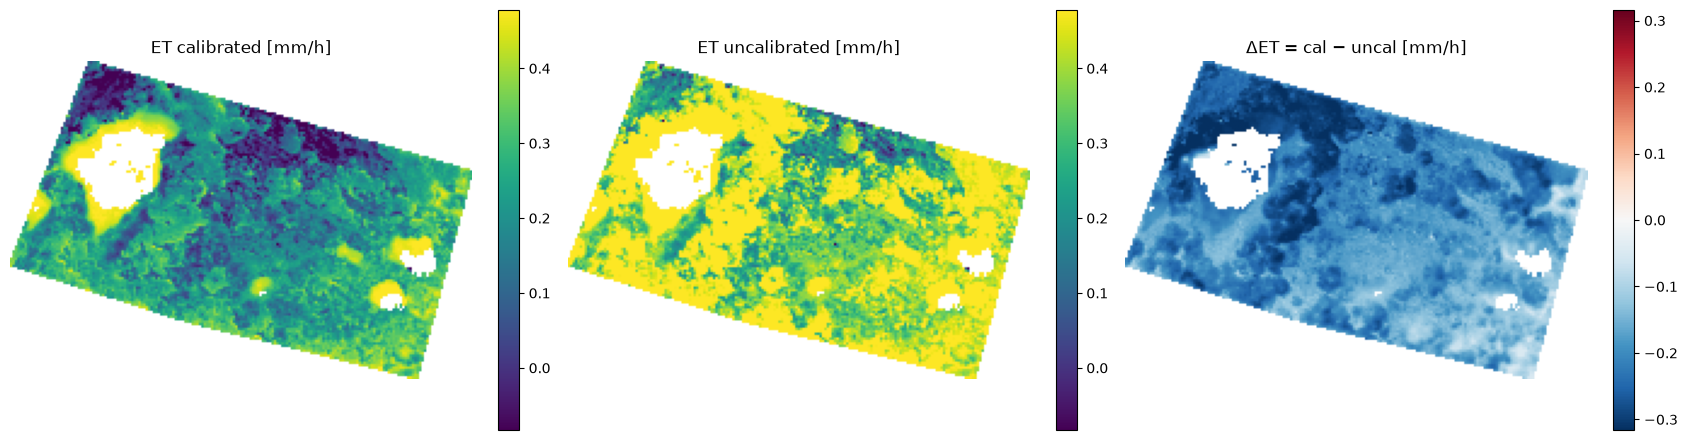

In [34]:
lo, hi = np.nanpercentile(et_both_1m['ET_cal'], [2, 98]) 
lim = np.nanpercentile(np.abs(dET), 98) 
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5)) 
panels = [(et_both_1m['ET_cal'], 'ET calibrated [mm/h]', 'viridis', {'vmin': lo, 'vmax': hi}),
           (et_both_1m['ET_uncal'],'ET uncalibrated [mm/h]', 'viridis', {'vmin': lo, 'vmax': hi}), 
           (dET, 'ΔET = cal − uncal [mm/h]','RdBu_r', {'vmin': -lim, 'vmax': lim})] 
for a, (arr, ttl, cm, kw) in zip(ax, panels): 
    im = a.imshow(np.where(arr > -2, arr, np.nan), cmap=cm, **kw) 
    plt.colorbar(im, ax=a, fraction=.046)
    a.set_title(ttl)
    a.axis('off')
plt.tight_layout()

In [35]:
H, LE, Rn, G = weather_station_buffer_median(et_both_1m['H_cal'], col_ws, row_ws, radius=1), weather_station_buffer_median(et_both_1m['LE_cal'], col_ws, row_ws, radius=1), \
        weather_station_buffer_median(et_both_1m['Rn_cal'], col_ws,row_ws, radius=1), weather_station_buffer_median(et_both_1m['G_cal'], col_ws, row_ws, radius=1)
print('model  β = {}  EF = {}'.format(H/LE, LE/(Rn-G)))
print(f"station  β = {ref['beta']}  EF = {ref['EF']}")

model  β = nan  EF = nan
station  β = 0.9807786420263489  EF = 0.5048653609626816


c:\Users\dance\OneDrive\Počítač\škola\diplomka\masters-thesis\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


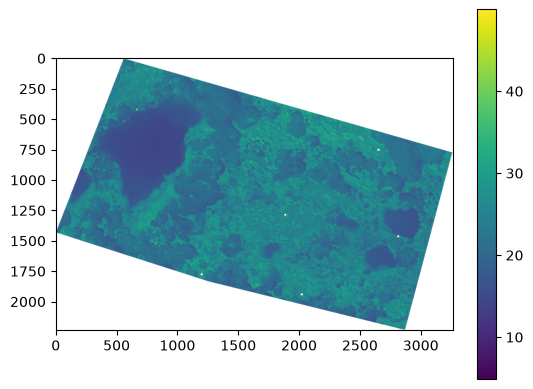

In [36]:
plt.imshow(data['lst_cal'])
plt.colorbar()

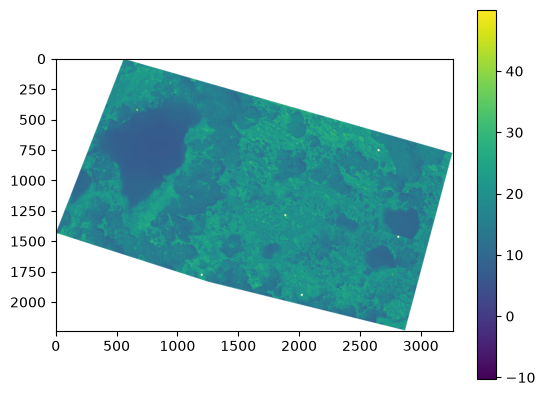

In [37]:
plt.imshow(data['tb_uncal'])
plt.colorbar()

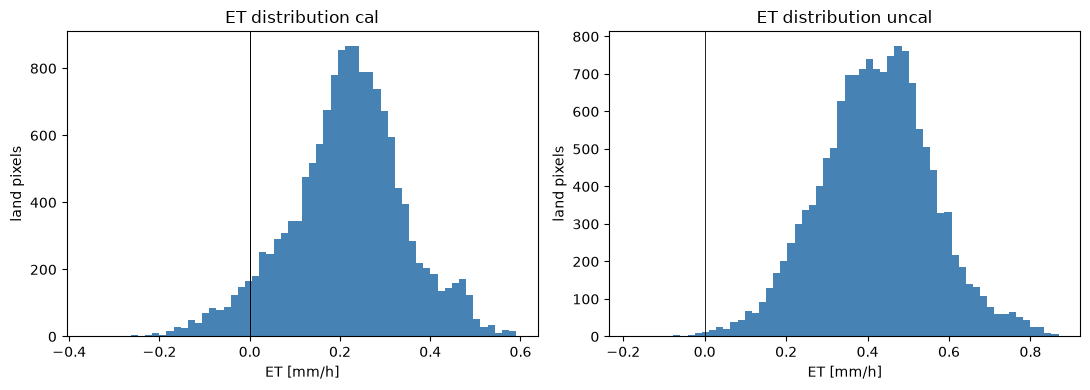

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(et_both_1m['ET_cal'].flatten(), 60, color='steelblue')
ax[0].axvline(0, color='k', lw=.6)
ax[0].set(xlabel='ET [mm/h]', ylabel='land pixels', title='ET distribution cal')
ax[1].hist(et_both_1m['ET_uncal'].flatten(), 60, color='steelblue')
ax[0].axvline(0, color='k', lw=.6)
ax[1].axvline(0, color='k', lw=.6)
ax[1].set(xlabel='ET [mm/h]', ylabel='land pixels', title='ET distribution uncal')
plt.tight_layout()

In [39]:
out = modules.fluxes.save_et_stack(f'{out_path}/{DATE}_et_stack_1m.tif', layers, prof, context)
#brb.to_parquet(f'{out_path}/{DATE}_breb.parquet')

**~2 m:**

In [40]:
et_both_2m, prof = modules.surface.load_stack(f'../results/{DATE}_et_stack.tif', names=layers.keys(), downsample=34)
dET = et_both_2m['ET_cal']-et_both_2m['ET_uncal']
valid = et_both_2m['valid']

RasterioIOError: ../results/20250807_et_stack.tif: No such file or directory

In [ ]:
lo, hi = np.nanpercentile(et_both_2m['ET_cal'], [2, 98]) 
lim = np.nanpercentile(np.abs(dET), 98) 
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5)) 
panels = [(et_both_2m['ET_cal'], 'ET calibrated [mm/h]', 'viridis', {'vmin': lo, 'vmax': hi}),
           (et_both_2m['ET_uncal'],'ET uncalibrated [mm/h]', 'viridis', {'vmin': lo, 'vmax': hi}), 
           (dET, 'ΔET = cal − uncal [mm/h]','RdBu_r', {'vmin': -lim, 'vmax': lim})] 
for a, (arr, ttl, cm, kw) in zip(ax, panels): 
    im = a.imshow(np.where(arr > -2, arr, np.nan), cmap=cm, **kw) 
    plt.colorbar(im, ax=a, fraction=.046)
    a.set_title(ttl)
    a.axis('off')
plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(et_both_2m['ET_cal'].flatten(), 60, color='steelblue')
ax[0].axvline(0, color='k', lw=.6)
ax[0].set(xlabel='ET [mm/h]', ylabel='land pixels', title='ET distribution cal')
ax[1].hist(et_both_2m['ET_uncal'].flatten(), 60, color='steelblue')
ax[0].axvline(0, color='k', lw=.6)
ax[1].axvline(0, color='k', lw=.6)
ax[1].set(xlabel='ET [mm/h]', ylabel='land pixels', title='ET distribution uncal')
plt.tight_layout()

In [ ]:
out = modules.save_et_stack(f'{out_path}/{DATE}_et_stack_2m.tif', layers, prof, context)
#brb.to_parquet(f'{out_path}/{DATE}_breb.parquet')